### The architecture based on this paper:


Wuqing Yu, Linfeng Yang, Xiangyu Liu,
AugLPN-NILM: Augmented lightweight parallel network for NILM embedding attention module over sequence to point,
Sustainable Energy, Grids and Networks,
Volume 38,
2024,
101378,
ISSN 2352-4677,
https://doi.org/10.1016/j.segan.2024.101378.
(https://www.sciencedirect.com/science/article/pii/S2352467724001073)


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(base_dir)

from src.metrics.energy_base_metrics import MAE, NEP, Precision_energy_based, Recall_energy_based, F1_energy_based

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu130
CUDA available: True


In [2]:
train_npy_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.npy')
test_npy_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.npy')
test_visualize_dir = os.path.join(base_dir, 'data', 'test', 'test_house2_for_visualize.npy')

on_threshold = {
    'Appliance1': 15,    # Fridge-Freezer
    'Appliance2': 20,    # Washing Machine
    'Appliance3': 10,    # Dishwasher
    'Appliance4': 10,    # Television
    'Appliance5': 20,    # Microwave
    'Appliance6': 20,    # Toaster
    'Appliance7': 5,     # Hi-Fi
    'Appliance8': 2000,  # Kettle
    'Appliance9': 15,    # Oven Extractor Fan
}
threshold = list(on_threshold.values())

app_min = np.array([0., 0., 0., 0., 0., 0., 0., 0., 0.])
app_max = np.array([1639., 2555., 2480.,  512., 1242., 1024., 1536., 2939.,  384.])

train_mean, train_std = (np.float64(494.62987145211497), np.float64(1088.939294395772))

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class NILMDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.transform = transform
        self.data_matrix = np.load(data_dir, mmap_mode='r')
        self.total_lines = self.data_matrix.shape[0]

    def __len__(self):
        return self.total_lines

    def __getitem__(self, idx):
        row = self.data_matrix[idx] 
        data = torch.tensor(row[:-9], dtype=torch.float32)
        label = torch.tensor(row[-9:], dtype=torch.float32)
        if self.transform:
            data = self.transform(data)
        data = data.unsqueeze(dim=0)  # Shape: (1, seq_len)
        return data, label

batch_size = 1024
train_dataset = NILMDataset(train_npy_dir)
test_dataset = NILMDataset(test_npy_dir)
visualize_dataset = NILMDataset(test_visualize_dir)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
visualize_loader = DataLoader(dataset=visualize_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 4586581
Test dataset size: 573322


 ### Enhanced Attention 
 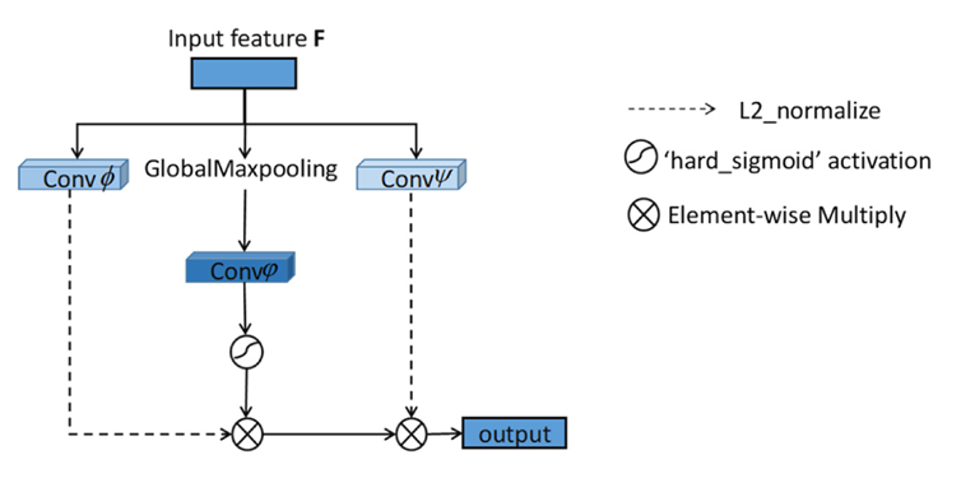

In [3]:
class EnhancedAttentionModule(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1x1 = nn.Conv1d(in_channels=in_channels, out_channels=in_channels, kernel_size=1)
        self.conv1x3 = nn.Conv1d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, padding=1)
        self.conv_mask = nn.Conv1d(in_channels=in_channels, out_channels=in_channels, kernel_size=1)
        
    def forward(self, F_map):
        feat1 = self.conv1x1(F_map)
        feat2 = self.conv1x3(F_map)
        feat1_norm = F.normalize(feat1, p=2, dim=1)
        feat2_norm = F.normalize(feat2, p=2, dim=1)
        mask = torch.max(F_map, dim=2, keepdim=True)[0]  # Shape: (batch_size, in_channels, 1)
        mask = self.conv_mask(mask)                     # Shape: (batch_size, in_channels, 1)
        mask = F.hardsigmoid(mask)                      
        out = (feat1_norm * mask) * feat2_norm  # Shape: (batch_size, in_channels, seq_len)
        return out

### Left Branch
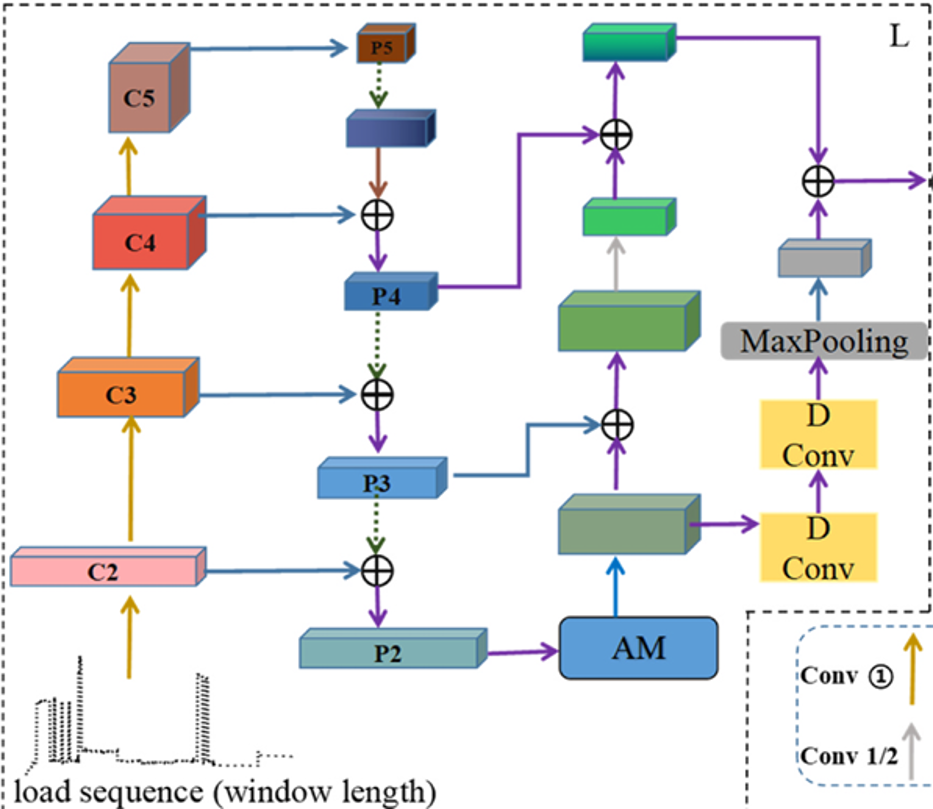

In [4]:
class LFPN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        # C2, C3, C4, C5 giảm chuỗi thời gian đi một nửa sau mỗi tầng
        self.conv_c2 = nn.Conv1d(in_channels, 32, kernel_size=3, stride=2, padding=1)  # 300 -> 150
        self.conv_c3 = nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1)           # 150 -> 75
        self.conv_c4 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)          # 75 -> 38
        self.conv_c5 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1)         # 38 -> 19
        
        # Top-down Pathway
        # Sử dụng Conv1d 1x1 để ép số kênh các nhánh ngang về 48
        self.lateral_c5 = nn.Conv1d(256, 48, kernel_size=1)
        self.lateral_c4 = nn.Conv1d(128, 48, kernel_size=1)
        self.lateral_c3 = nn.Conv1d(64, 48, kernel_size=1)
        self.lateral_c2 = nn.Conv1d(32, 48, kernel_size=1)
        
        # Lớp Conv1d 3x3 làm mịn đặc trưng sau khi Up-sampling
        self.smooth_p4 = nn.Conv1d(48, 48, kernel_size=3, padding=1)
        self.smooth_p3 = nn.Conv1d(48, 48, kernel_size=3, padding=1)
        self.smooth_p2 = nn.Conv1d(48, 48, kernel_size=3, padding=1)
        
    def forward(self, x):
        # x shape: (batch_size, 1, 300)
        # Bottom-up pathway 
        c2 = F.relu(self.conv_c2(x))       # (batch_size, 32, 150)
        c3 = F.relu(self.conv_c3(c2))      # (batch_size, 64, 75)
        c4 = F.relu(self.conv_c4(c3))      # (batch_size, 128, 38)
        c5 = F.relu(self.conv_c5(c4))      # (batch_size, 256, 19)
        
        # Top-down pathway 
        p5 = self.lateral_c5(c5)           # (batch_size, 48, 19)
        
        p5_up = F.interpolate(p5, size=c4.shape[2], mode='linear', align_corners=False) # (batch_size, 48, 38)
        p4 = self.smooth_p4(p5_up) + self.lateral_c4(c4)                                # (batch_size, 48, 38)
        
        p4_up = F.interpolate(p4, size=c3.shape[2], mode='linear', align_corners=False) # (batch_size, 48, 75)
        p3 = self.smooth_p3(p4_up) + self.lateral_c3(c3)                                # (batch_size, 48, 75)
        
        p3_up = F.interpolate(p3, size=c2.shape[2], mode='linear', align_corners=False) # (batch_size, 48, 150)
        p2 = self.smooth_p2(p3_up) + self.lateral_c2(c2)                                # (batch_size, 48, 150)
        
        return c2, c3, c4, c5, p2, p3, p4, p5

### Right Part
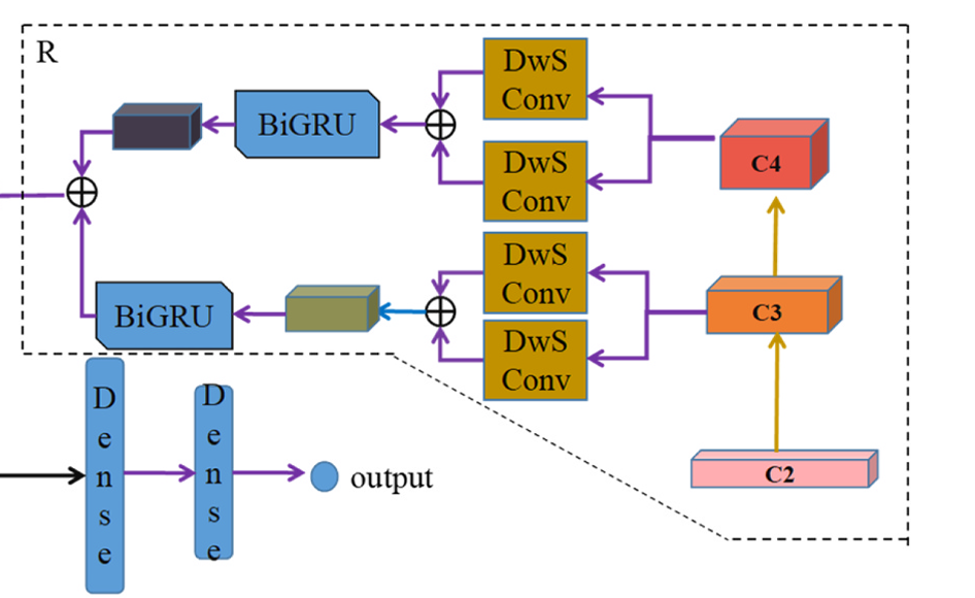

In [5]:
class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.depthwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_channels
        )
        # Pointwise Conv1d 1x1
        self.pointwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1
        )
        self.act = nn.ReLU()
        self.bn = nn.BatchNorm1d(out_channels)
        
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return self.bn(self.act(x))


class TemporalBranchR(nn.Module):
    def __init__(self):
        super().__init__()
        self.dsc3_k3 = DepthwiseSeparableConv1d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.dsc3_k5 = DepthwiseSeparableConv1d(in_channels=64, out_channels=64, kernel_size=5, padding=2)
        self.reduce_c3 = nn.Conv1d(in_channels=64, out_channels=32, kernel_size=1)
        self.bigru_c3 = nn.GRU(input_size=32, hidden_size=32, num_layers=1, batch_first=True, bidirectional=True)
        self.dsc4_k3 = DepthwiseSeparableConv1d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.dsc4_k5 = DepthwiseSeparableConv1d(in_channels=128, out_channels=128, kernel_size=5, padding=2)
        self.reduce_c4 = nn.Conv1d(in_channels=128, out_channels=32, kernel_size=1)
        self.bigru_c4 = nn.GRU(input_size=32, hidden_size=32, num_layers=1, batch_first=True, bidirectional=True)
        
    def forward(self, c3, c4):
        out_dsc3 = self.dsc3_k3(c3) + self.dsc3_k5(c3) # (B, 64, 75)
        out_red3 = self.reduce_c3(out_dsc3)            # (B, 32, 75)
        out_perm3 = out_red3.permute(0, 2, 1)          # (B, 75, 32)
        gru3_out, _ = self.bigru_c3(out_perm3)         # (B, 75, 64)
        gru3_out = gru3_out.permute(0, 2, 1)           # (B, 64, 75)
        
        # Downsample đầu ra BiGRU của C3 từ chiều dài 75 về 38 để cộng được với nhánh C4
        gru3_out_down = F.adaptive_max_pool1d(gru3_out, output_size=c4.shape[2]) # (B, 64, 38)
        
        out_dsc4 = self.dsc4_k3(c4) + self.dsc4_k5(c4) # (B, 128, 38)
        out_red4 = self.reduce_c4(out_dsc4)            # (B, 32, 38)
        out_perm4 = out_red4.permute(0, 2, 1)          # (B, 38, 32)
        gru4_out, _ = self.bigru_c4(out_perm4)         # (B, 38, 64)
        gru4_out = gru4_out.permute(0, 2, 1)           # (B, 64, 38)
        
        feat_temporal = gru3_out_down + gru4_out       # (B, 64, 38)
        return feat_temporal

In [ ]:
class SpatialBranchL(nn.Module):
    def __init__(self):
        super().__init__()
        self.am = EnhancedAttentionModule(in_channels=48)       
        self.down1_to_2 = nn.Conv1d(in_channels=48, out_channels=48, kernel_size=3, stride=2, padding=1) # 150 -> 75
        self.down2_to_3 = nn.Conv1d(in_channels=48, out_channels=48, kernel_size=3, stride=2, padding=1) # 75 -> 38
        self.lateral_p3 = nn.Conv1d(48, 48, kernel_size=1)
        self.dconv1 = nn.Conv1d(in_channels=48, out_channels=48, kernel_size=3, padding=2, dilation=2)
        self.dconv2 = nn.Conv1d(in_channels=48, out_channels=48, kernel_size=3, padding=4, dilation=4)
        
    def forward(self, p2, p3, p4):
        # p2: (B, 48, 150), p3: (B, 48, 75), p4: (B, 48, 38)
        f_deep1 = self.am(p2)                                    # (B, 48, 150)
        f_deep2_proj = self.down1_to_2(f_deep1)                 # (B, 48, 75)
        f_deep2 = f_deep2_proj + self.lateral_p3(p3)                             # (B, 48, 75)
        f_deep3_proj = self.down2_to_3(f_deep2)                 # (B, 48, 38/37)
        f_deep3_proj = F.adaptive_max_pool1d(f_deep3_proj, output_size=p4.shape[2]) # Khớp chính xác length p4 -> (B, 48, 38)
        f_deep3 = f_deep3_proj + p4                              # (B, 48, 38)        
        out_dconv1 = F.relu(self.dconv1(f_deep1))                # (B, 48, 150)
        out_dconv1_down = F.adaptive_max_pool1d(out_dconv1, output_size=f_deep2.shape[2]) # (B, 48, 75)
        feat_joint2 = out_dconv1_down + f_deep2                  # (B, 48, 75)
        out_dconv2 = F.relu(self.dconv2(feat_joint2))            # (B, 48, 75)
        out_dconv2_down = F.adaptive_max_pool1d(out_dconv2, output_size=f_deep3.shape[2]) # (B, 48, 38)
        feat_joint3 = out_dconv2_down + f_deep3                  # (B, 48, 38)
        return feat_joint3

class AugLPNNILM(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.lfpn = LFPN(in_channels=in_channels)
        self.spatial_L = SpatialBranchL()
        self.temporal_R = TemporalBranchR()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=112 * 38, out_features=56)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(in_features=56, out_features=10)
        self.fc3 = nn.Linear(in_features=10, out_features=1) # Sequence-to-Point (S2P)
        
    def forward(self, x):
        # x: (B, 1, 300)
        c2, c3, c4, c5, p2, p3, p4, p5 = self.lfpn(x)
        feat_L = self.spatial_L(p2, p3, p4) # (B, 48, 38)
        feat_R = self.temporal_R(c3, c4)   # (B, 64, 38)     
        feat_concat = torch.cat([feat_L, feat_R], dim=1) # (B, 112, 38)
        x_flat = self.flatten(feat_concat)
        x_fc1 = self.dropout(self.relu(self.fc1(x_flat)))
        x_fc2 = self.dropout(self.relu(self.fc2(x_fc1)))
        out = self.fc3(x_fc2) # (B, 1)
        return out

In [8]:
def Precision_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_predict.sum(axis = 0) 
    numerator = np.minimum(y_predict, y_target).sum(axis = 0) 
    return (numerator + alpha) / (denominator + alpha)

def Recall_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)

def F1_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    p_denominator = y_predict.sum(axis = 0)
    r_denominator = y_target.sum(axis = 0)
    precision = (numerator + alpha) / (p_denominator + alpha)
    recall = (numerator + alpha) / (r_denominator + alpha)
    return 2 * precision * recall / (precision + recall)

def NEP_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.abs(y_target - y_predict).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)

In [9]:
class WeightedMAELoss(nn.Module):
    def __init__(self, weight_factor=15.0, weight_factor_off = 1.0, threshold_watt=10.0, appliance_min=0.0, appliance_max=1.0):
        super(WeightedMAELoss, self).__init__()
        self.weight_factor = weight_factor
        self.threshold_watt = threshold_watt
        self.appliance_min = appliance_min
        self.appliance_max = appliance_max
        self.weight_factor_off = weight_factor_off

    def forward(self, pred, target_scaled):
        loss = torch.abs(pred - target_scaled)
        target_watt = target_scaled * (self.appliance_max - self.appliance_min) + self.appliance_min   # chuẩn hóa ngược để xem giá trị nguyên bản có lớn hơn 0 ko
        weights = torch.where(target_watt > self.threshold_watt, self.weight_factor, self.weight_factor_off)     # tạo ra 1 tensor cùng shape nếu tmdk thì thay bởi giá trị đầu tiên ko thì 1.0
        weighted_loss = loss * weights
        return weighted_loss.mean()

In [12]:
def train_auglpn(epochs, save_dir, app_num, device = device, lr = 5e-4, taking_threshold = np.inf, weight_factor=1.0, weight_factor_off = 1.0):
    ignore_threshold = threshold[app_num - 1]
    model = AugLPNNILM(in_channels=1).to(device)
    
    if os.path.exists(save_dir):
        model.load_state_dict(torch.load(save_dir, map_location=device))
                
    criterion = WeightedMAELoss(appliance_min = app_min[app_num - 1], appliance_max = app_max[app_num - 1], weight_factor = weight_factor, threshold_watt = ignore_threshold, weight_factor_off = weight_factor_off) # Sử dụng L1 Loss theo yêu cầu
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    
    min_eval_loss = taking_threshold
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")):
            # Chuẩn hóa đầu vào Z-score
            data = (data - train_mean) / train_std
            # Chuẩn hóa đầu ra Min-Max cho thiết bị cụ thể
            target = target[:, [app_num - 1]]
            target = (target - app_min[app_num - 1]) / (app_max[app_num - 1] - app_min[app_num - 1])
            data, target = data.to(device).to(torch.float32), target.to(device).to(torch.float32)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        avg_train_loss = train_loss / (batch_idx + 1)
        print(f'EPOCH: {epoch+1}, average train loss (L1): {avg_train_loss:.6f}')

        model.eval()
        eval_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data_eval, target_eval) in enumerate(tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Eval]")):
                # Chuẩn hóa đầu vào Z-score
                data_eval = (data_eval - train_mean) / train_std
               # Chuẩn hóa đầu ra Min-Max
                target_eval = target_eval[:, [app_num - 1]]
                target_eval = (target_eval - app_min[app_num - 1]) / (app_max[app_num - 1] - app_min[app_num - 1])                
                data_eval, target_eval = data_eval.to(device).to(torch.float32), target_eval.to(device).to(torch.float32)
                pred = model(data_eval)
                eval_loss += criterion(pred, target_eval).item()               
            avg_eval_loss = eval_loss / (batch_idx + 1)            
            if avg_eval_loss < min_eval_loss:
                min_eval_loss = avg_eval_loss
                torch.save(model.state_dict(), save_dir)
                print(f'>>> new best model with eval Loss: {avg_eval_loss:.6f} <<<')               
            print(f'EPOCH: {epoch+1}, average eval loss: {avg_eval_loss:.6f}')           
    print(f'Done training model for appliance {app_num}')

In [13]:
def tester_auglpn(save_dir, app_num, device = device):
    model = AugLPNNILM(in_channels=1).to(device)
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.eval()
    pred = []
    ground_truth = []
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(tqdm(visualize_loader, desc="Testing")):
            # Chuẩn hóa đầu vào Z-score
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device).to(torch.float32)
            target_watt = target_eval[:, [app_num - 1]].numpy().flatten().tolist()
            ground_truth.extend(target_watt)
            pred_scaled = model(data_eval) # (B, 1)
            pred_watt = pred_scaled.cpu().numpy() * (app_max[app_num - 1] - app_min[app_num - 1]) + app_min[app_num - 1]
            pred_watt = np.clip(pred_watt, a_min=0, a_max=None).flatten().tolist()
            pred.extend(pred_watt)
    pred = np.array(pred).reshape(-1, 1)
    ground_truth = np.array(ground_truth).reshape(-1, 1)
    
    plt.figure(figsize = (16, 9))
    plt.plot(ground_truth, color = 'r', label = f'Ground Truth of Appliance {app_num}')
    plt.plot(pred, color = 'b', label = f'Prediction of Appliance {app_num}')
    plt.title(f'Comparison between Ground Truth and AugLPN-NILM Prediction for Appliance {app_num}')
    plt.ylabel('Power (Watts)')
    plt.xlabel('Time steps')
    plt.legend()
    plt.show()
    
    print(f'F1 Energy Based: {F1_energy_based_fixed(pred, ground_truth)[0]:.4f}')
    print(f'MAE: {MAE(pred, ground_truth)[0]:.4f}')    
    return pred, ground_truth

In [15]:
os.makedirs(os.path.join(base_dir, 'checkpoints', 'auglpn'), exist_ok = True)

In [14]:
model_save_dir1 = os.path.join(base_dir, 'checkpoints', 'auglpn', 'auglpn_app1.pth')
model_save_dir2 = os.path.join(base_dir, 'checkpoints', 'auglpn', 'auglpn_app2.pth')
model_save_dir3 = os.path.join(base_dir, 'checkpoints', 'auglpn', 'auglpn_app3.pth')
model_save_dir5 = os.path.join(base_dir, 'checkpoints', 'auglpn', 'auglpn_app5.pth')
model_save_dir8 = os.path.join(base_dir, 'checkpoints', 'auglpn', 'auglpn_app8.pth')

In [21]:
train_auglpn(epochs=20, save_dir=model_save_dir1, app_num=1, lr=5e-4)

Epoch 1/20 [Train]: 100%|██████████| 4480/4480 [14:09<00:00,  5.27it/s]


EPOCH: 1, average train loss (L1): 0.011449


Epoch 1/20 [Eval]: 100%|██████████| 560/560 [00:50<00:00, 11.08it/s]


>>> new best model with eval Loss: 0.011318 <<<
EPOCH: 1, average eval loss: 0.011318


Epoch 2/20 [Train]: 100%|██████████| 4480/4480 [13:37<00:00,  5.48it/s]


...

EPOCH: 19, average eval loss: 0.008246


Epoch 20/20 [Train]: 100%|██████████| 4480/4480 [13:30<00:00,  5.53it/s]


EPOCH: 20, average train loss (L1): 0.006670


Epoch 20/20 [Eval]: 100%|██████████| 560/560 [00:50<00:00, 11.14it/s]

EPOCH: 20, average eval loss: 0.008172
Done training model for appliance 1


Testing: 100%|██████████| 560/560 [01:00<00:00,  9.32it/s]


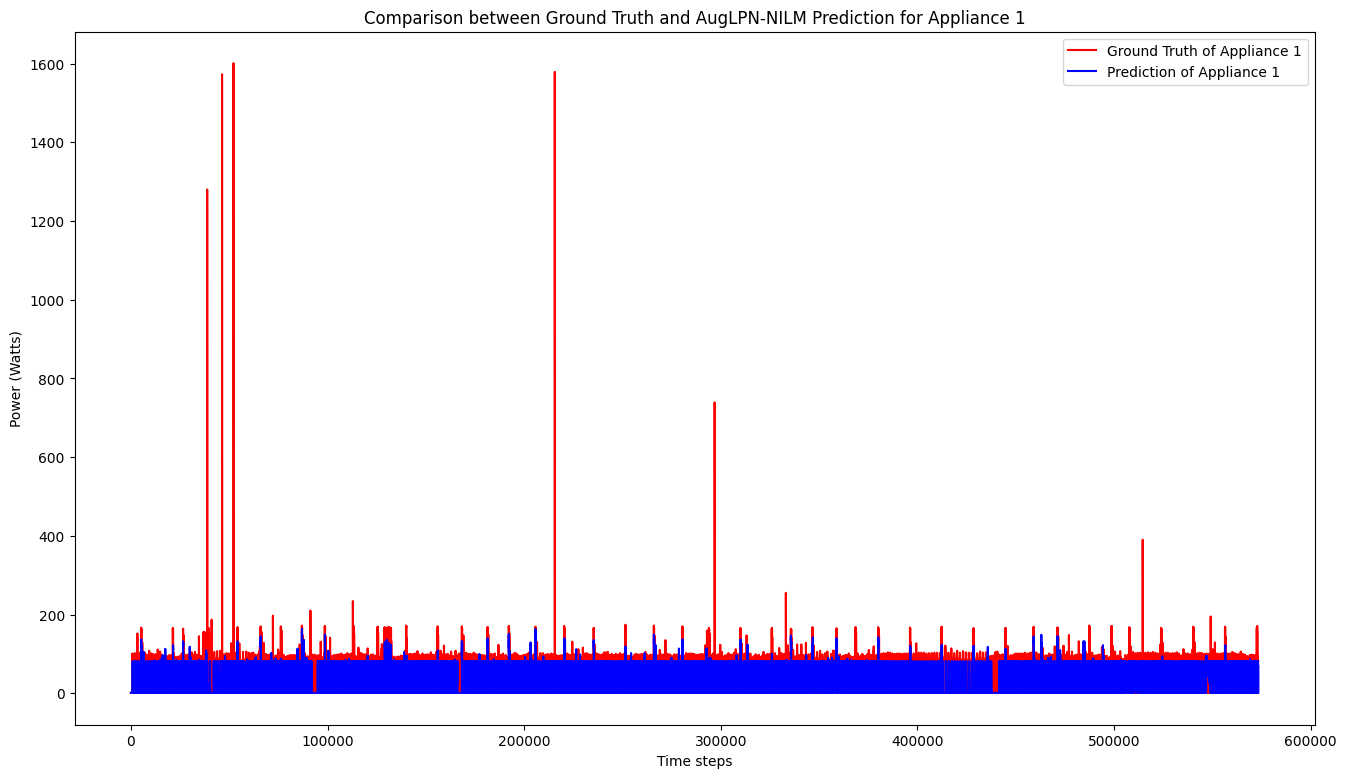

F1 Energy Based: 0.7722
MAE: 15.4690


(array([[1.04114528],
        [1.04114528],
        [1.04114528],
        ...,
        [1.04114528],
        [1.04114528],
        [1.04114528]], shape=(573324, 1)),
 array([[ 1.],
        [ 1.],
        [ 1.],
        ...,
        [81.],
        [82.],
        [82.]], shape=(573324, 1)))

In [17]:
tester_auglpn(save_dir=model_save_dir1, app_num=1)

In [14]:
train_auglpn(epochs=20, save_dir=model_save_dir2, app_num=2, lr=5e-5, taking_threshold = 0.004161)

Epoch 1/20 [Train]: 100%|██████████| 4480/4480 [17:02<00:00,  4.38it/s]


EPOCH: 1, average train loss (L1): 0.003638


Epoch 1/20 [Eval]: 100%|██████████| 560/560 [00:55<00:00, 10.15it/s]


>>> new best model with eval Loss: 0.004060 <<<
EPOCH: 1, average eval loss: 0.004060


Epoch 2/20 [Train]: 100%|██████████| 4480/4480 [15:08<00:00,  4.93it/s]


...

EPOCH: 4, average train loss (L1): 0.003377


Epoch 4/20 [Eval]: 100%|██████████| 560/560 [01:00<00:00,  9.26it/s]


EPOCH: 4, average eval loss: 0.007715


Epoch 5/20 [Train]:  24%|██▍       | 1073/4480 [03:35<11:24,  4.98it/s]


KeyboardInterrupt: 

Testing: 100%|██████████| 560/560 [01:01<00:00,  9.17it/s]


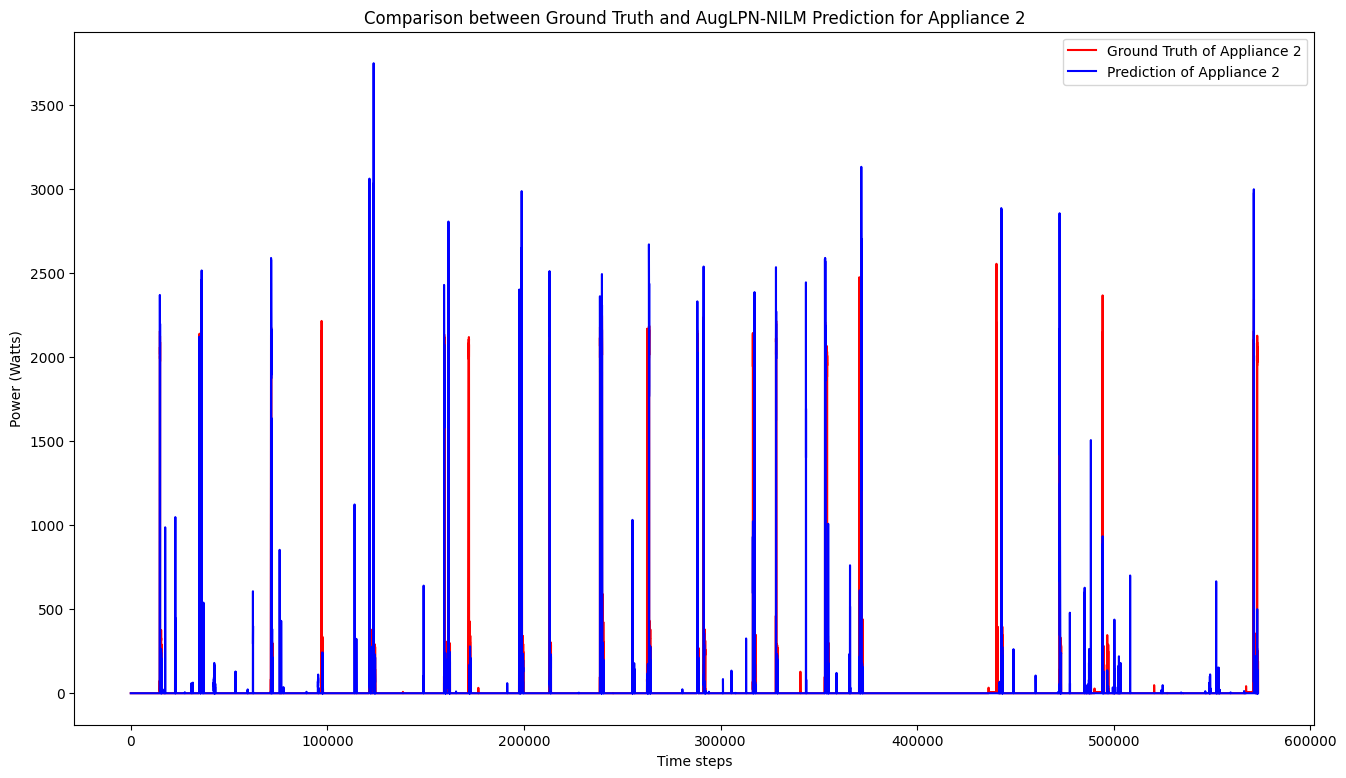

F1 Energy Based: 0.7173
MAE: 9.1891


(array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(573324, 1)),
 array([[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [28.],
        [54.],
        [ 5.]], shape=(573324, 1)))

In [18]:
tester_auglpn(save_dir=model_save_dir2, app_num=2)

In [ ]:
train_auglpn(epochs=20, save_dir=model_save_dir3, app_num=3, lr=5e-5)

Epoch 1/20 [Train]: 100%|██████████| 4480/4480 [14:56<00:00,  5.00it/s]


EPOCH: 1, average train loss (L1): 0.040411


Epoch 1/20 [Eval]: 100%|██████████| 560/560 [01:00<00:00,  9.23it/s]


>>> new best model with eval Loss: 0.019563 <<<
EPOCH: 1, average eval loss: 0.019563


Epoch 2/20 [Train]: 100%|██████████| 4480/4480 [15:07<00:00,  4.94it/s]


...

EPOCH: 15, average train loss (L1): 0.008380


Epoch 15/20 [Eval]: 100%|██████████| 560/560 [00:51<00:00, 10.80it/s]


EPOCH: 15, average eval loss: 0.016066


Epoch 16/20 [Train]:   3%|▎         | 117/4480 [00:22<14:14,  5.10it/s]


KeyboardInterrupt: 

In [20]:
train_auglpn(epochs=20, save_dir=model_save_dir3, app_num=3, lr=5e-4)

Epoch 1/20 [Train]: 100%|██████████| 4480/4480 [15:01<00:00,  4.97it/s]


EPOCH: 1, average train loss (L1): 0.017234


Epoch 1/20 [Eval]: 100%|██████████| 560/560 [01:02<00:00,  8.90it/s]


>>> new best model with eval Loss: 0.019979 <<<
EPOCH: 1, average eval loss: 0.019979


Epoch 2/20 [Train]: 100%|██████████| 4480/4480 [14:13<00:00,  5.25it/s]


...

EPOCH: 8, average train loss (L1): 0.008660


Epoch 8/20 [Eval]: 100%|██████████| 560/560 [00:51<00:00, 10.79it/s]


EPOCH: 8, average eval loss: 0.015720


Epoch 9/20 [Train]:   1%|          | 23/4480 [00:04<16:08,  4.60it/s]


KeyboardInterrupt: 

In [16]:
tester_auglpn(save_dir=model_save_dir3, app_num=3)

Testing:   6%|▌         | 34/560 [00:03<00:59,  8.88it/s]


KeyboardInterrupt: 

Testing: 100%|██████████| 560/560 [00:52<00:00, 10.66it/s]


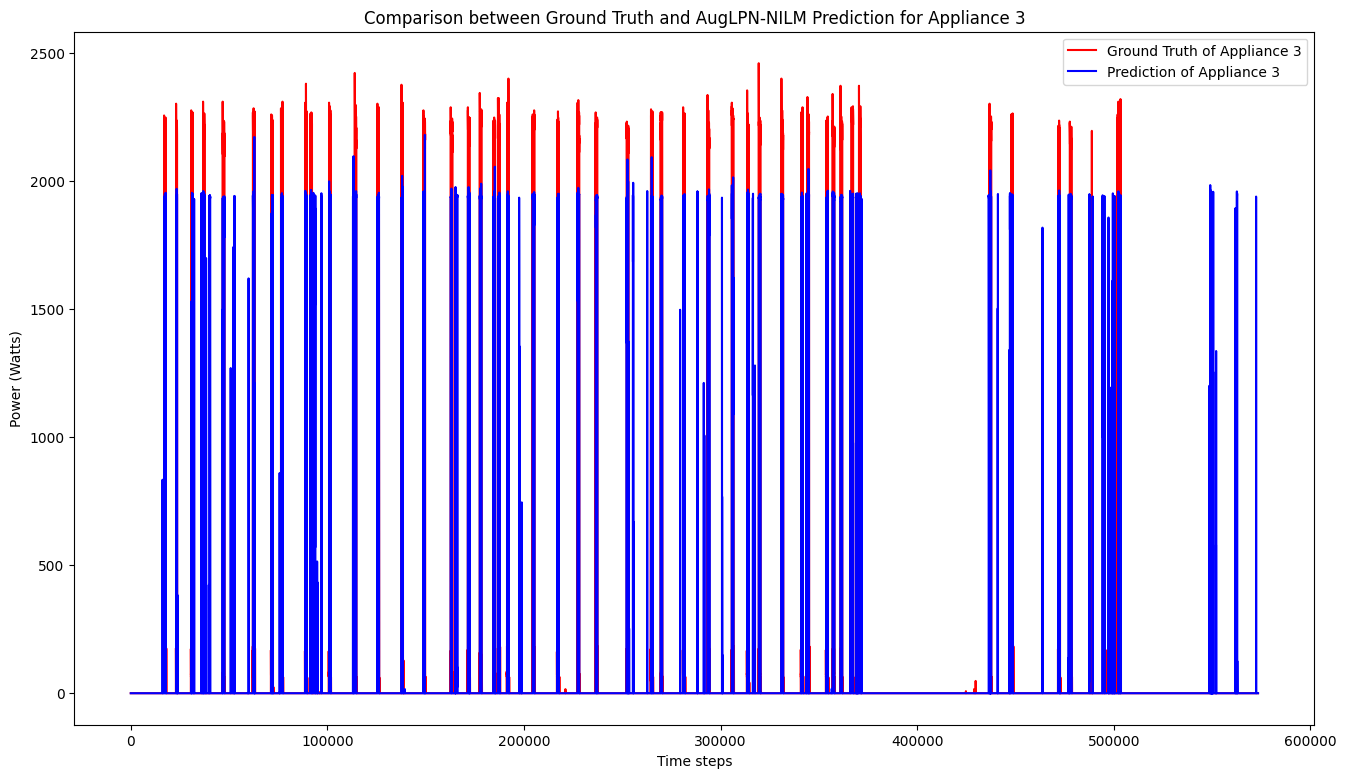

F1 Energy Based: 0.7311
MAE: 30.8045


(array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(573324, 1)),
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(573324, 1)))

In [21]:
tester_auglpn(save_dir=model_save_dir3, app_num=3)

In [22]:
train_auglpn(epochs=20, save_dir=model_save_dir5, app_num=5, lr=1e-5, weight_factor = 10.0)

Epoch 1/20 [Train]: 100%|██████████| 4480/4480 [14:14<00:00,  5.24it/s]


EPOCH: 1, average train loss (L1): 0.065016


Epoch 1/20 [Eval]: 100%|██████████| 560/560 [01:00<00:00,  9.24it/s]


>>> new best model with eval Loss: 0.040905 <<<
EPOCH: 1, average eval loss: 0.040905


Epoch 2/20 [Train]: 100%|██████████| 4480/4480 [14:01<00:00,  5.32it/s]


...

EPOCH: 15, average train loss (L1): 0.013160


Epoch 15/20 [Eval]: 100%|██████████| 560/560 [01:00<00:00,  9.18it/s]


EPOCH: 15, average eval loss: 0.016026


Epoch 16/20 [Train]:   5%|▌         | 233/4480 [00:47<14:19,  4.94it/s]


KeyboardInterrupt: 

Testing: 100%|██████████| 560/560 [01:00<00:00,  9.25it/s]


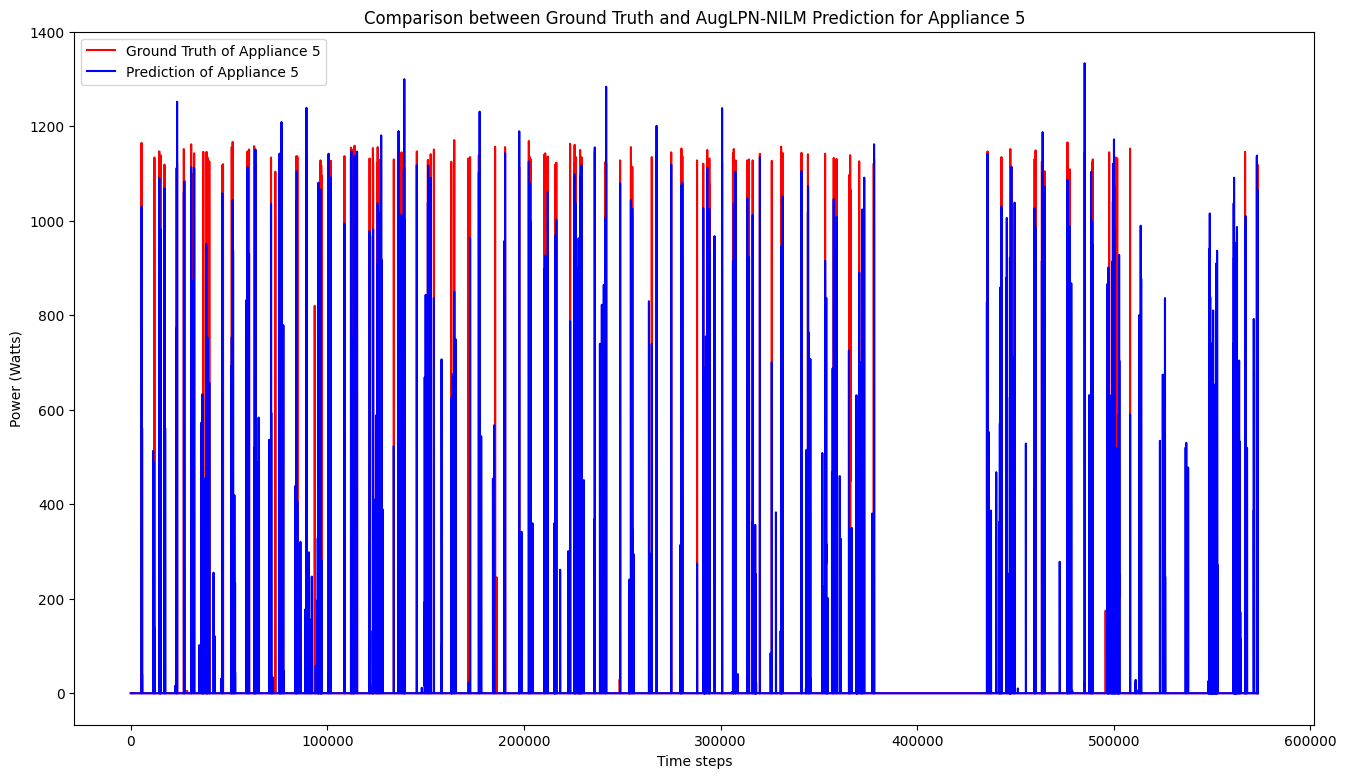

F1 Energy Based: 0.4290
MAE: 5.1415


(array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(573324, 1)),
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(573324, 1)))

In [23]:
tester_auglpn(save_dir=model_save_dir5, app_num=5)

In [15]:
train_auglpn(epochs=20, save_dir=model_save_dir8, app_num=8, lr=5e-5, weight_factor = 10.0)

Epoch 1/20 [Train]: 100%|██████████| 4480/4480 [14:58<00:00,  4.99it/s]


EPOCH: 1, average train loss (L1): 0.021621


Epoch 1/20 [Eval]: 100%|██████████| 560/560 [01:00<00:00,  9.25it/s]


>>> new best model with eval Loss: 0.008353 <<<
EPOCH: 1, average eval loss: 0.008353


Epoch 2/20 [Train]: 100%|██████████| 4480/4480 [15:43<00:00,  4.75it/s]


...

EPOCH: 7, average train loss (L1): 0.018103


Epoch 7/20 [Eval]: 100%|██████████| 560/560 [00:51<00:00, 10.93it/s]


EPOCH: 7, average eval loss: 0.009007


Epoch 8/20 [Train]:   1%|▏         | 66/4480 [00:12<14:11,  5.18it/s]


KeyboardInterrupt: 

Testing: 100%|██████████| 560/560 [00:49<00:00, 11.23it/s]


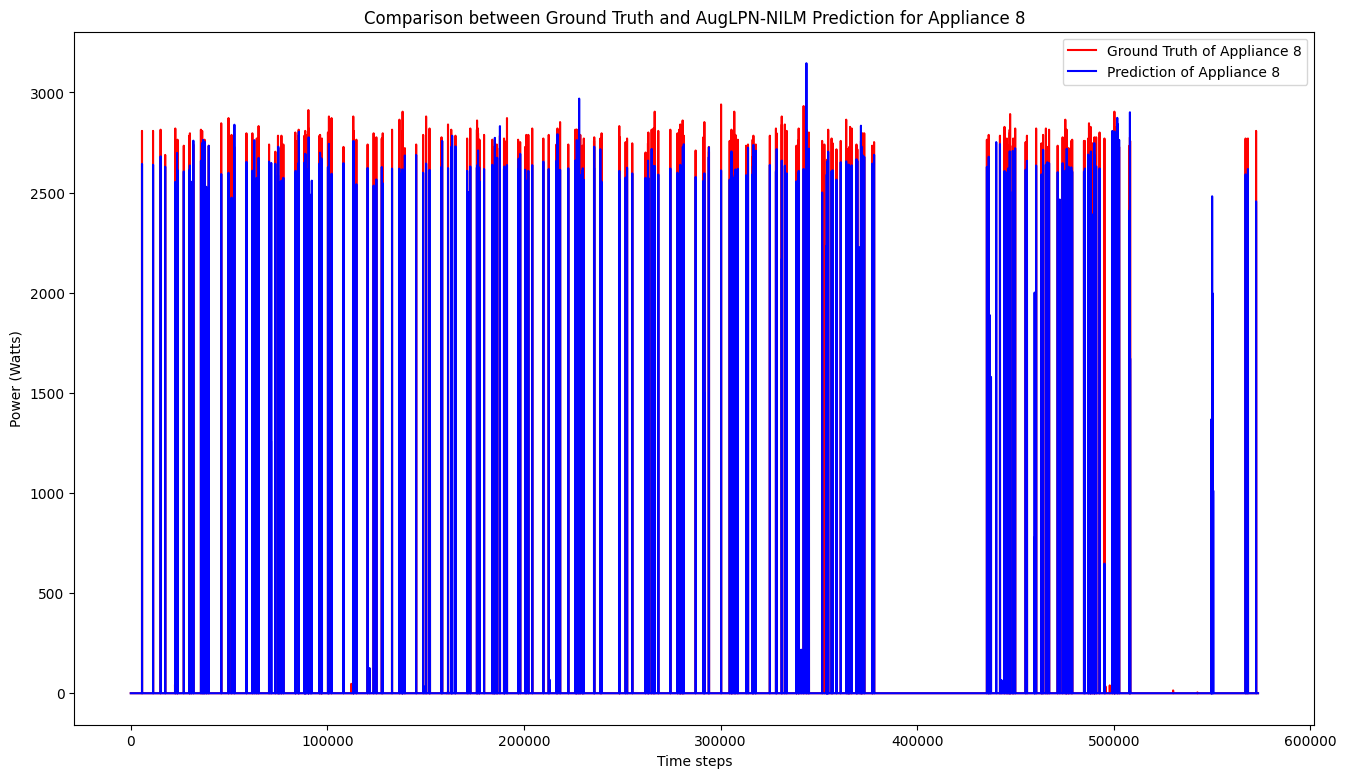

F1 Energy Based: 0.8756
MAE: 4.8713


(array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(573324, 1)),
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(573324, 1)))

In [16]:
tester_auglpn(save_dir=model_save_dir8, app_num=8)